In [74]:
# Cell 0: Config (replace ALPHA=0.80 with nothing — computed per country below)
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as stats
import numpy as np

PATHS = {
    'M0': '../output/results/M0_results_5YCDS.csv',
    'M1': '../output/results/M1_results_5YCDS.csv',
    'M2': '../output/results/M2_results_5YCDS.csv',
}
DATE_COL    = 'date'
COUNTRY_COL = 'country'
DD_COL      = 'distance_to_distress'
CDS_COL     = 'cds_spread'
HORIZONS    = [1, 2, 4, 8]
EXPORTERS   = ['Saudi Arabia', 'Abu Dhabi', 'Qatar', 'Colombia',
               'Mexico', 'Brazil', 'Egypt', 'Malaysia']
CONTROLS    = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa',
               'South Korea', 'Thailand', 'Turkey']
RECOVERY = 0.40
HORIZON  = 5

In [77]:
# Cell 1: Build panel with observed CDS, model DDs, and RNS
def compute_rns(df, t=HORIZON):
    V  = df['implied_V'].values
    sA = df['implied_sigma_V'].values
    B  = df['B_f'].values
    rf = df['risk_free_rate'].values
    sqt = np.sqrt(t)
    d1 = (np.log(V / B) + (rf + 0.5 * sA**2) * t) / (sA * sqt)
    d2 = d1 - sA * sqt

    V_fcl = V * (1 - norm.cdf(d1)) + B * np.exp(-rf * t) * norm.cdf(d2)
    rns = (1/t) * np.log(B / V_fcl) - rf

    return rns * 10000  # bps

RNS_COLS = [DATE_COL, COUNTRY_COL, 'implied_V', 'implied_sigma_V', 'B_f', 'risk_free_rate']

df_obs = pd.read_csv(PATHS['M0'], parse_dates=[DATE_COL],
                     usecols=[DATE_COL, COUNTRY_COL, CDS_COL])

dd_frames = [df_obs.set_index([DATE_COL, COUNTRY_COL])]

for model_name, path in PATHS.items():
    df = pd.read_csv(path, parse_dates=[DATE_COL],
                     usecols=[DATE_COL, COUNTRY_COL, DD_COL] + RNS_COLS[2:])
    df[f'RNS_{model_name}'] = compute_rns(df)
    df = df.rename(columns={DD_COL: f'DD_{model_name}'})
    df = df[[DATE_COL, COUNTRY_COL, f'DD_{model_name}', f'RNS_{model_name}']]
    dd_frames.append(df.set_index([DATE_COL, COUNTRY_COL]))

panel = pd.concat(dd_frames, axis=1).reset_index()
panel = panel[panel[COUNTRY_COL].isin(EXPORTERS + CONTROLS)].dropna()
panel['group']    = panel[COUNTRY_COL].apply(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
panel['exporter'] = (panel['group'] == 'Exporter').astype(float)

panel

,date,country,cds_spread,DD_M0,RNS_M0,DD_M1,RNS_M1,DD_M2,RNS_M2,group,exporter
0,2015-01-04,Abu Dhabi,69.65999,20.746751,-3.599551e-13,16.884515,-3.599551e-13,17.004334,-3.599551e-13,Exporter,1.0
1,2015-01-11,Abu Dhabi,71.70000,20.750363,-2.081668e-13,16.079664,-2.081668e-13,18.411733,-2.081668e-13,Exporter,1.0
2,2015-01-18,Abu Dhabi,68.68999,20.746132,-2.818926e-14,16.042590,-2.818926e-14,16.450459,-2.818926e-14,Exporter,1.0
3,2015-01-25,Abu Dhabi,68.67999,20.745758,-2.818926e-14,16.027682,-2.818926e-14,16.176663,-2.818926e-14,Exporter,1.0
4,2015-02-01,Abu Dhabi,68.70000,20.738952,1.431147e-13,15.573514,1.431147e-13,15.963429,1.431147e-13,Exporter,1.0
...,...,...,...,...,...,...,...,...,...,...,...
8869,2024-12-01,Turkey,251.12000,-0.384709,1.425872e+03,-0.380030,1.418767e+03,-0.384708,1.425870e+03,Control,0.0
8870,2024-12-08,Turkey,241.90000,-0.360856,1.390355e+03,-0.356184,1.383253e+03,-0.360855,1.390353e+03,Control,0.0
8871,2024-12-15,Turkey,247.11000,-0.364650,1.396211e+03,-0.360640,1.390086e+03,-0.364649,1.396209e+03,Control,0.0
8872,2024-12-22,Turkey,256.52000,-0.367613,1.400700e+03,-0.363341,1.394263e+03,-0.367612,1.400699e+03,Control,0.0


In [78]:
# Cell 2: Summary tables
mean_table = panel.groupby(COUNTRY_COL)[
    ['cds_spread', 'DD_M0', 'DD_M1', 'DD_M2']
].mean().round(2)
mean_table['group'] = mean_table.index.map(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
print("Mean CDS (bps):")
print(mean_table.sort_values(['group', COUNTRY_COL]).to_string())

cv_table = panel.groupby(COUNTRY_COL)[
    ['cds_spread', 'DD_M0', 'DD_M1', 'DD_M2']
].apply(lambda x: x.std() / x.mean()).round(4)
cv_table['group'] = cv_table.index.map(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
print("\nCoefficient of Variation:")
print(cv_table.sort_values(['group', COUNTRY_COL]).to_string())

Mean CDS (bps):
              cds_spread  DD_M0  DD_M1  DD_M2     group
country                                                
Chile              75.23   3.49   3.37   3.50   Control
China              68.75  10.64   9.92  10.64   Control
Indonesia         117.18   6.71   6.08   6.71   Control
Philippines        77.79  10.85   9.39  10.84   Control
South Africa      228.06   4.20   4.05   4.21   Control
South Korea        40.96  10.36   9.54  10.39   Control
Thailand           60.30  13.03  10.95  12.91   Control
Turkey            362.42   3.31   3.14   3.32   Control
Abu Dhabi          57.83  11.84   9.65  11.39  Exporter
Brazil            219.78   6.65   6.40   6.67  Exporter
Colombia          169.70   4.27   3.98   4.28  Exporter
Egypt             554.35   5.94   5.35   5.92  Exporter
Malaysia           84.07   8.80   7.77   8.82  Exporter
Mexico            124.99   5.42   5.17   5.43  Exporter
Qatar              68.87   8.04   6.89   8.00  Exporter
Saudi Arabia       85.09   6.97 

In [72]:
for model in ['M0', 'M1', 'M2']:
    below_one = (panel[f'DD_{model}'] < 1).sum()
    at_zero   = (panel[f'DD_{model}'] <= 0).sum()
    print(f"{model}: DD < 1: {below_one}, DD <= 0: {at_zero}")

M0: DD < 1: 130, DD <= 0: 60
M1: DD < 1: 130, DD <= 0: 60
M2: DD < 1: 175, DD <= 0: 52


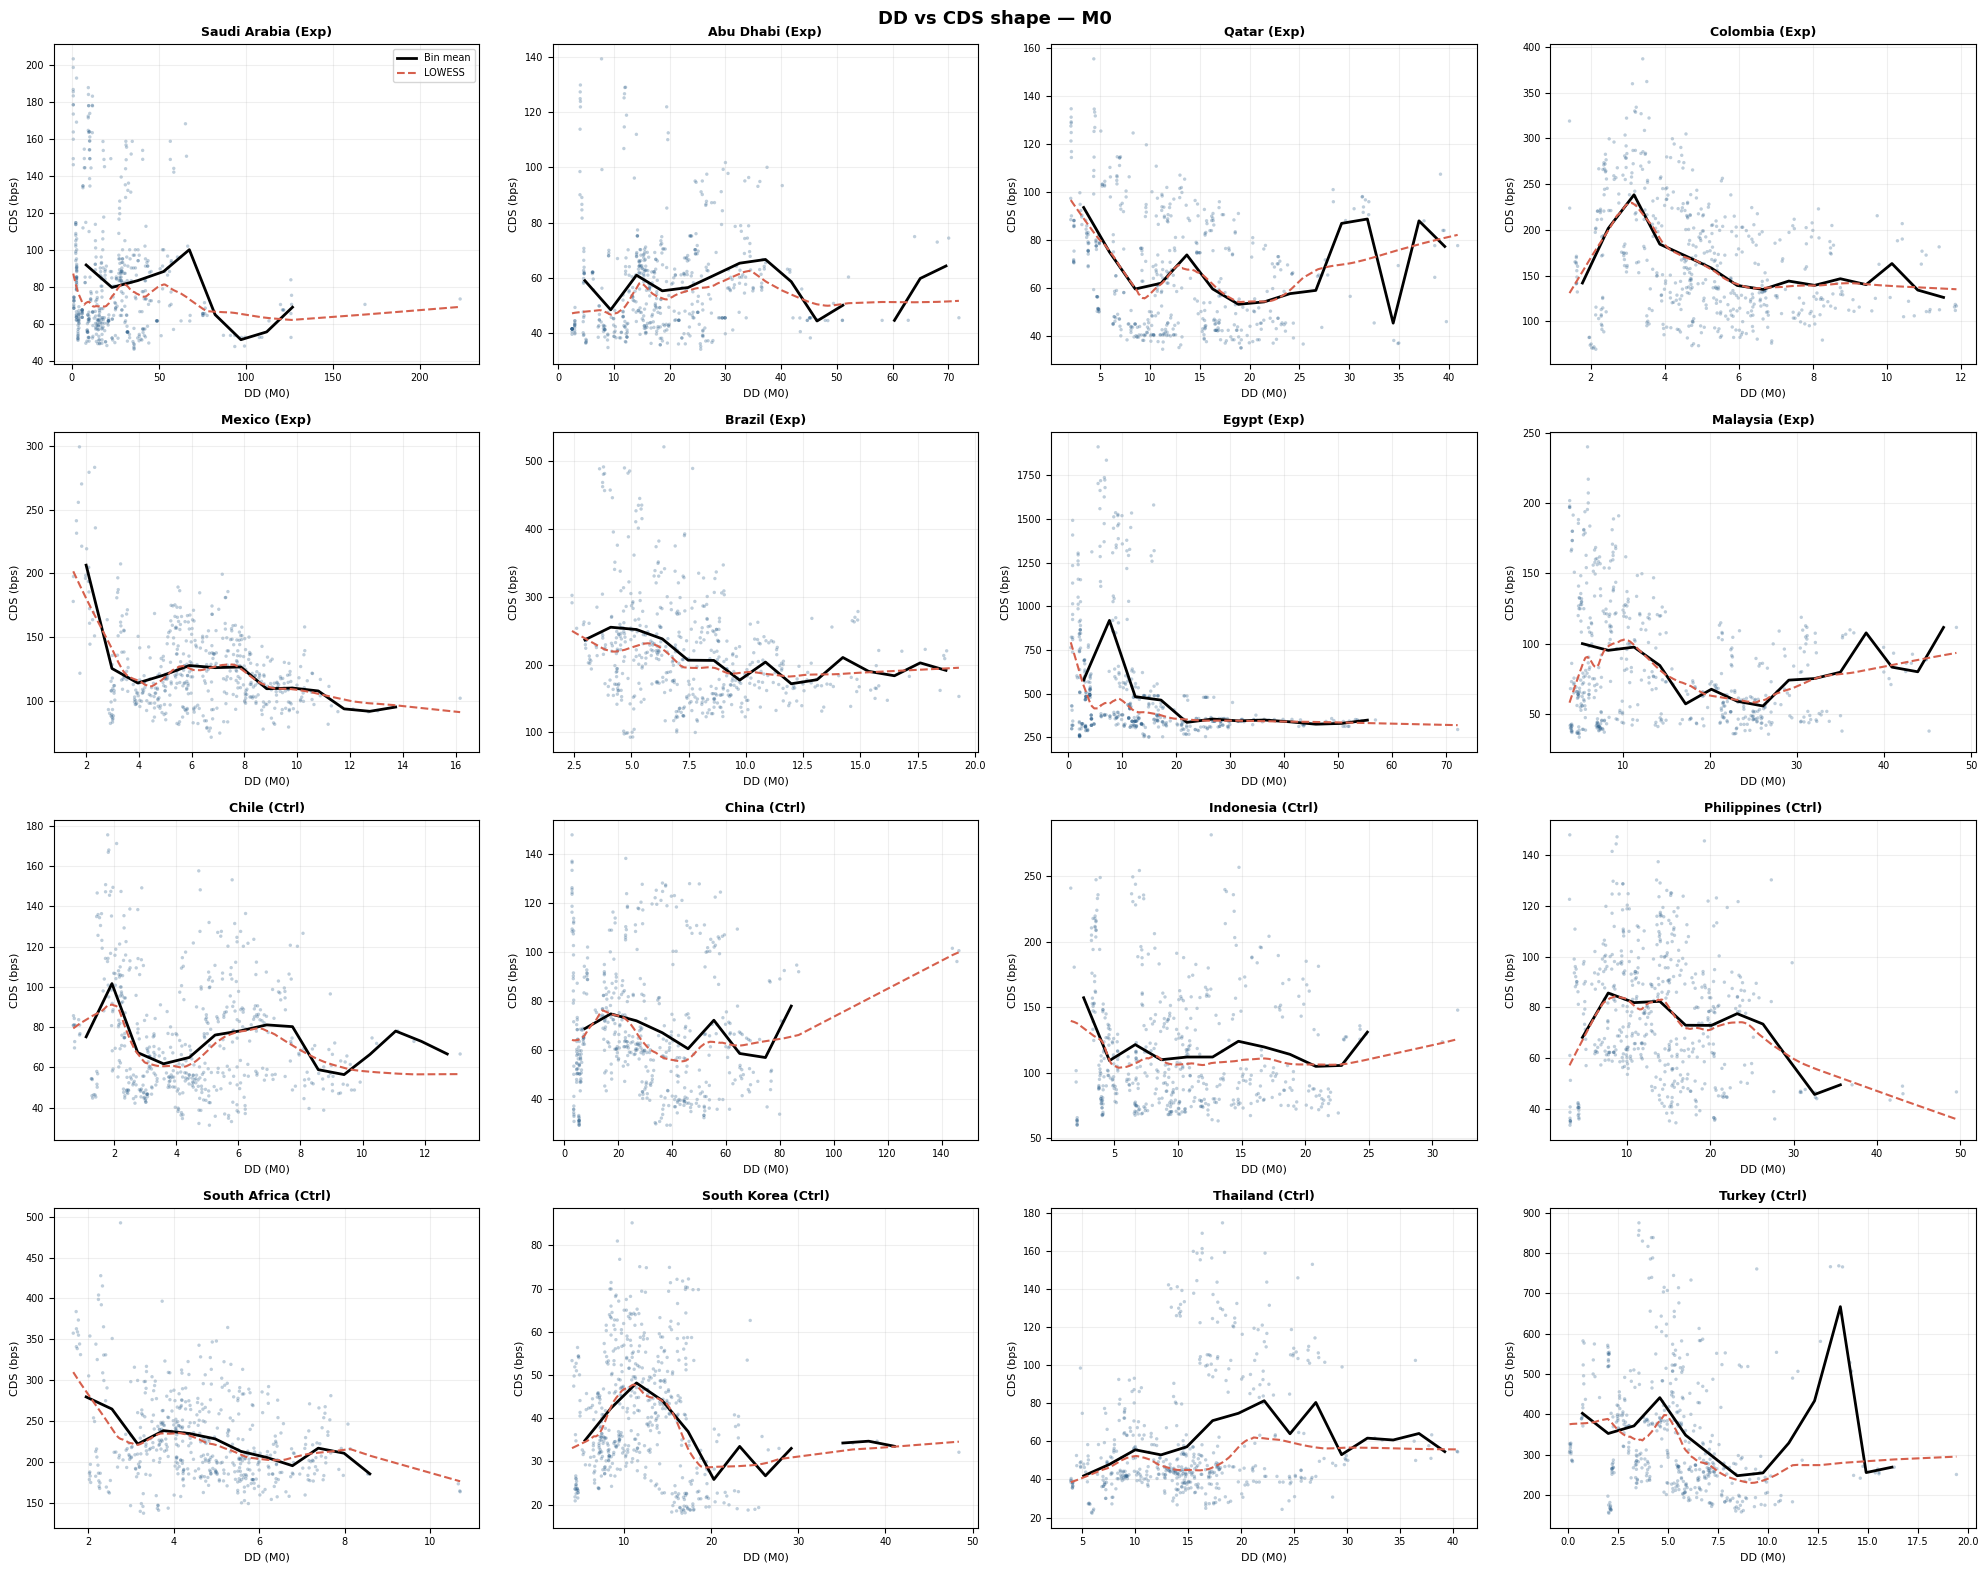

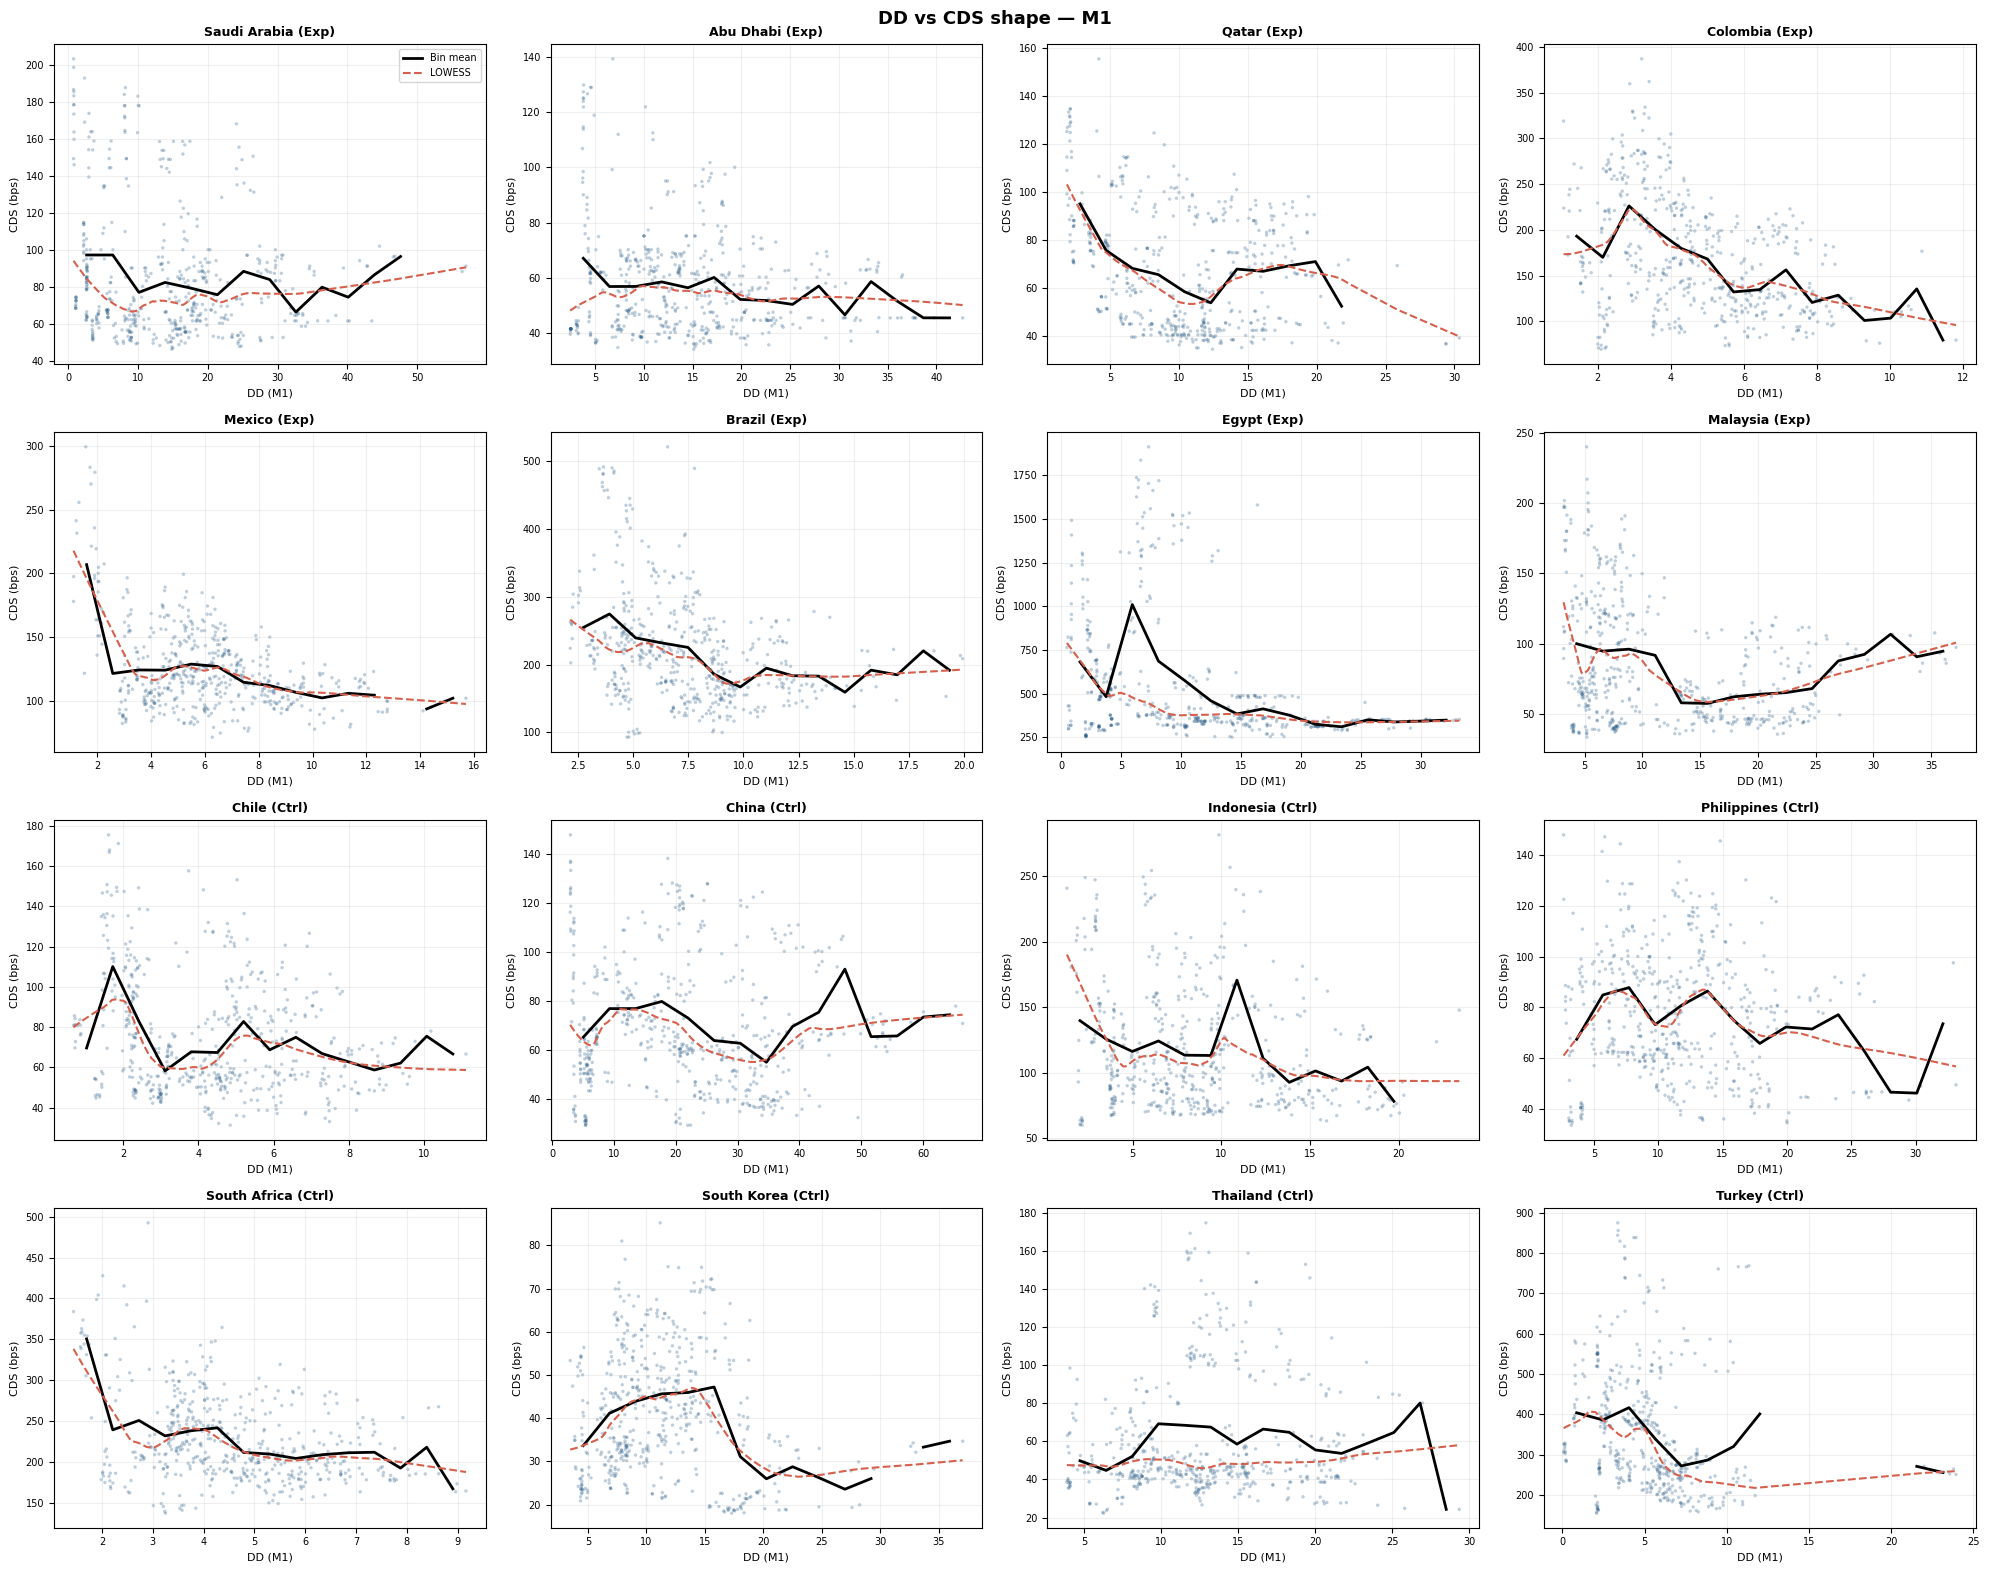

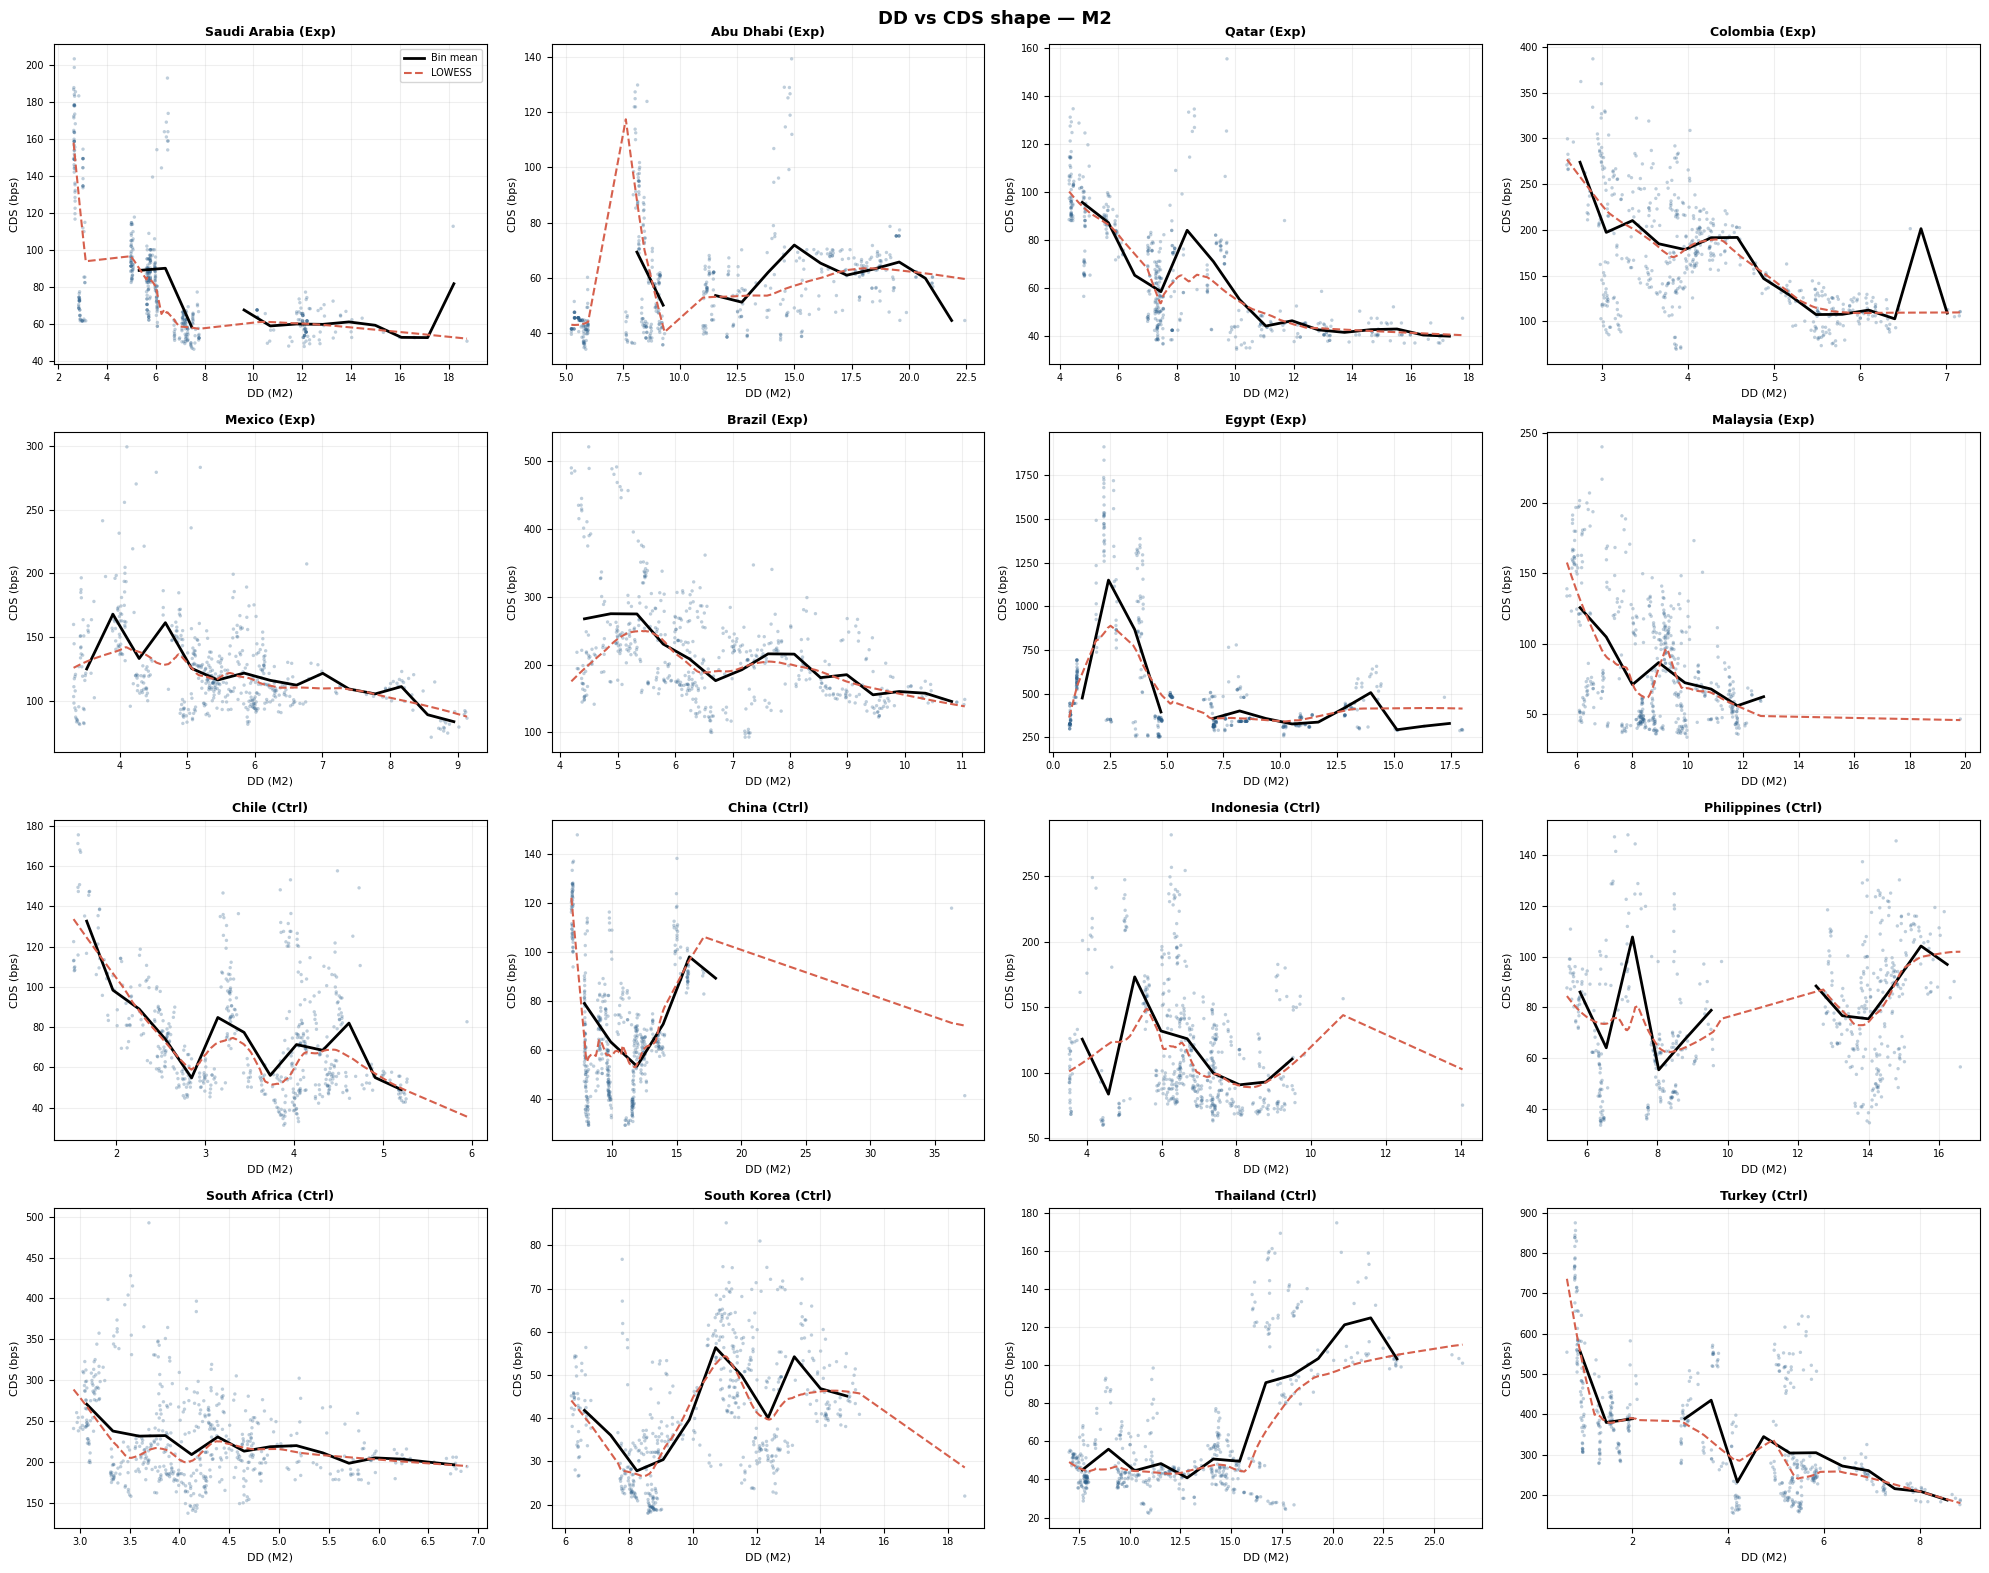

In [73]:
from scipy.stats import binned_statistic

def plot_dd_cds_shape(model_name, countries=None, ncols=4, figsize_per=(5, 4)):
    dd_col = f'DD_{model_name}'
    if countries is None:
        countries = EXPORTERS + CONTROLS

    nrows = int(np.ceil(len(countries) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes = np.atleast_2d(axes).flatten()

    for i, country in enumerate(countries):
        ax = axes[i]
        d = panel[panel[COUNTRY_COL] == country]\
            .dropna(subset=[dd_col, CDS_COL]).copy()
        d = d[d[dd_col] > 0]

        if len(d) < 20:
            ax.set_visible(False)
            continue

        x = d[dd_col].values
        y = d[CDS_COL].values

        # Raw scatter
        ax.scatter(x, y, s=6, alpha=0.3, color='#2C5F8A', edgecolors='none')

        # Binned means — shows the average shape without assuming a form
        n_bins = 15
        try:
            means, edges, _ = binned_statistic(x, y, statistic='mean', bins=n_bins)
            mids = (edges[:-1] + edges[1:]) / 2
            ax.plot(mids, means, color='black', lw=2, label='Bin mean')
        except Exception:
            pass

        # LOWESS smoother — completely nonparametric
        try:
            import statsmodels.nonparametric.smoothers_lowess as lowess_mod
            order  = np.argsort(x)
            smooth = lowess_mod.lowess(y[order], x[order], frac=0.3, return_sorted=True)
            ax.plot(smooth[:, 0], smooth[:, 1], color='#d6604d', lw=1.5,
                    linestyle='--', label='LOWESS')
        except Exception:
            pass

        group = 'Exp' if country in EXPORTERS else 'Ctrl'
        ax.set_title(f'{country} ({group})', fontsize=9, fontweight='bold')
        ax.set_xlabel(f'DD ({model_name})', fontsize=8)
        ax.set_ylabel('CDS (bps)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)

    axes[0].legend(fontsize=7)
    for j in range(len(countries), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'DD vs CDS shape — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

for model in ['M0', 'M1', 'M2']:
    plot_dd_cds_shape(model)

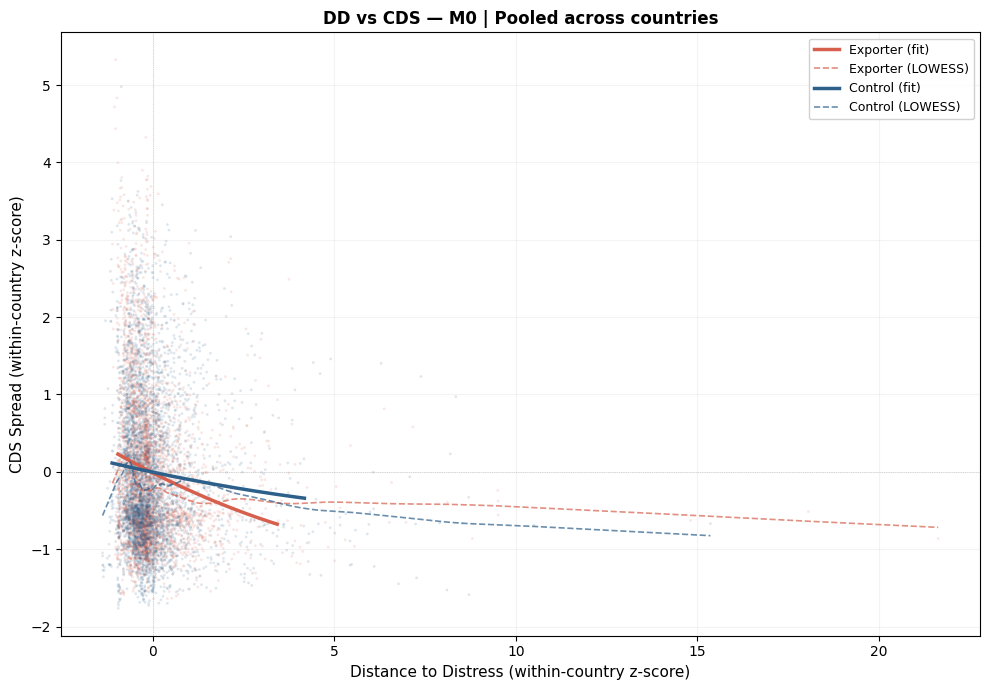

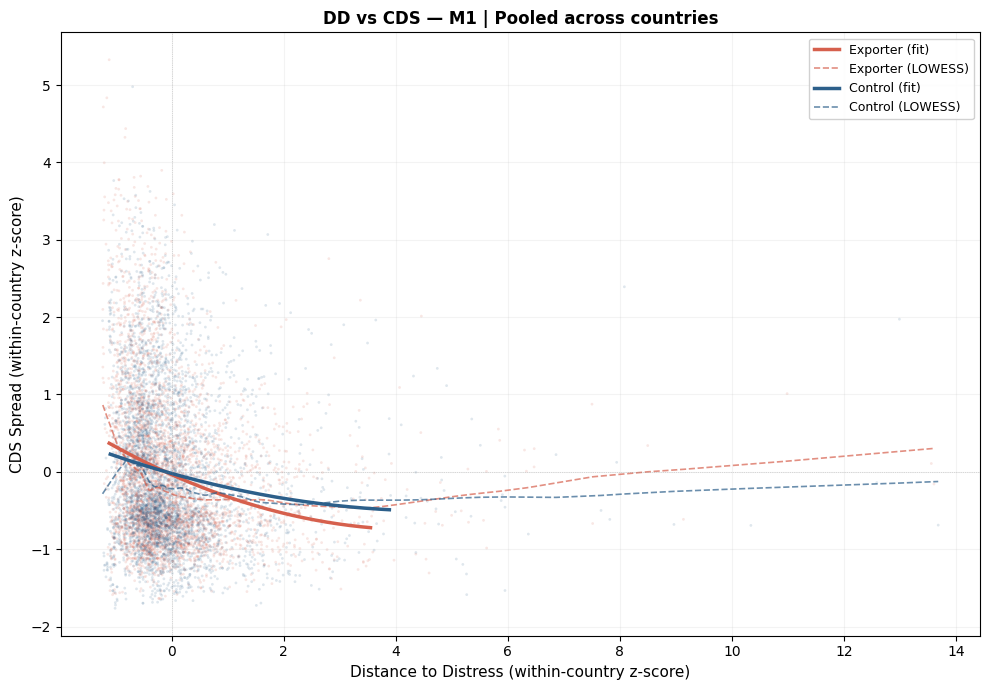

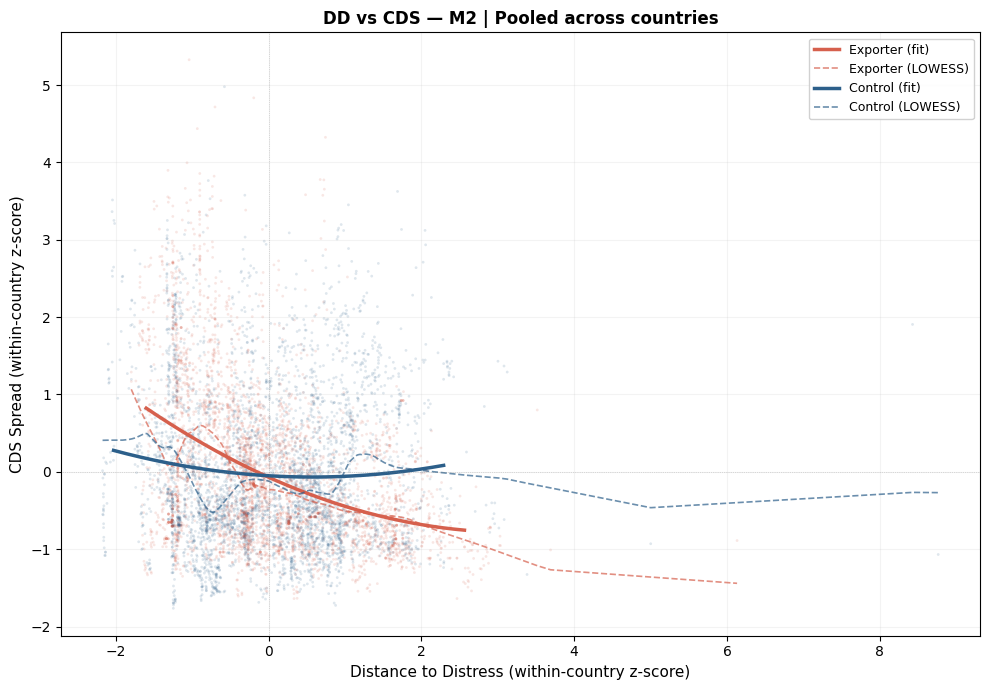

In [63]:
import statsmodels.nonparametric.smoothers_lowess as lowess_mod

def plot_dd_cds_pooled(model_name, figsize=(10, 7)):
    dd_col = f'DD_{model_name}'

    fig, ax = plt.subplots(figsize=figsize)

    colors = {'Exporter': '#d6604d', 'Control': '#2C5F8A'}

    for group_name, group_countries in [('Exporter', EXPORTERS), ('Control', CONTROLS)]:
        d = panel[panel[COUNTRY_COL].isin(group_countries)]\
            .dropna(subset=[dd_col, CDS_COL]).copy()
        d = d[d[dd_col] > 0]

        # Z-score CDS within country so scale differences don't dominate
        d['cds_z'] = d.groupby(COUNTRY_COL)[CDS_COL]\
                      .transform(lambda s: (s - s.mean()) / s.std())
        d['dd_z']  = d.groupby(COUNTRY_COL)[dd_col]\
                      .transform(lambda s: (s - s.mean()) / s.std())
        d = d.dropna(subset=['cds_z', 'dd_z'])

        x = d['dd_z'].values
        y = d['cds_z'].values
        color = colors[group_name]

        # Scatter
        ax.scatter(x, y, s=4, alpha=0.15, color=color, edgecolors='none')

        # Power law fit in z-score space is just OLS with quadratic term
        # (power law requires positive x, z-scores can be negative — use polynomial instead)
        # Fit: y = a + b*x + c*x^2 with c>0 enforced via the data shape
        order  = np.argsort(x)
        x_s, y_s = x[order], y[order]

        # Convex fit: degree-2 polynomial, plot only the fitted curve
        coeffs = np.polyfit(x_s, y_s, 2)
        x_fit  = np.linspace(np.percentile(x, 1), np.percentile(x, 99), 300)
        y_fit  = np.polyval(coeffs, x_fit)
        ax.plot(x_fit, y_fit, color=color, lw=2.5, label=f'{group_name} (fit)')

        # LOWESS to show actual shape
        smooth = lowess_mod.lowess(y_s, x_s, frac=0.2, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color=color, lw=1.2,
                linestyle='--', alpha=0.7, label=f'{group_name} (LOWESS)')

    ax.axhline(0, color='grey', lw=0.5, ls=':', alpha=0.5)
    ax.axvline(0, color='grey', lw=0.5, ls=':', alpha=0.5)
    ax.set_xlabel('Distance to Distress (within-country z-score)', fontsize=11)
    ax.set_ylabel('CDS Spread (within-country z-score)', fontsize=11)
    ax.set_title(f'DD vs CDS — {model_name} | Pooled across countries',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()

for model in ['M0', 'M1', 'M2']:
    plot_dd_cds_pooled(model)

In [64]:
for model in ['M0', 'M1', 'M2']:
    dd_col = f'DD_{model}'
    d = panel.dropna(subset=[dd_col, CDS_COL]).copy()
    d = d[d[dd_col] > 0]
    d['cds_z'] = d.groupby(COUNTRY_COL)[CDS_COL].transform(lambda s: (s - s.mean()) / s.std())
    d['dd_z']  = d.groupby(COUNTRY_COL)[dd_col].transform(lambda s: (s - s.mean()) / s.std())
    d['dd_z2'] = d['dd_z'] ** 2
    d = d.dropna(subset=['cds_z', 'dd_z'])

    X = sm.add_constant(d[['dd_z', 'dd_z2']])
    res = sm.OLS(d['cds_z'], X).fit(cov_type='cluster',
                                     cov_kwds={'groups': d[COUNTRY_COL].values})
    print(f"\n{model}: c={res.params['dd_z2']:.4f}, p={res.pvalues['dd_z2']:.4f}, R²={res.rsquared:.3f}")


M0: c=0.0093, p=0.0100, R²=0.016

M1: c=0.0291, p=0.0000, R²=0.037

M2: c=0.0527, p=0.0057, R²=0.055


In [43]:
# Cell: Convert DD to model-implied CDS spreads and recompute summary stats
def dd_to_spread(dd, alpha, T=T_CDS, LGD=LGD):
    pd_hat = norm.cdf(-alpha * dd)
    spread = -np.log(1 - LGD * pd_hat) / T * 10000
    return spread

for model in ['M0', 'M1', 'M2']:
    panel[f'CDS_{model}'] = panel.apply(
        lambda r: dd_to_spread(r[f'DD_{model}'], alpha_dict[r[COUNTRY_COL]]),
        axis=1
    )

cds_cols = ['cds_spread', 'CDS_M0', 'CDS_M1', 'CDS_M2']

mean_table = panel.groupby(COUNTRY_COL)[cds_cols].mean().round(2)
mean_table['group'] = mean_table.index.map(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
print("Mean CDS (bps) — observed vs model-implied:")
print(mean_table.sort_values(['group', COUNTRY_COL]).to_string())

cv_table = panel.groupby(COUNTRY_COL)[cds_cols].apply(
    lambda x: x.std() / x.mean()
).round(4)
cv_table['group'] = cv_table.index.map(
    lambda x: 'Exporter' if x in EXPORTERS else 'Control'
)
print("\nCoefficient of Variation:")
print(cv_table.sort_values(['group', COUNTRY_COL]).to_string())

Mean CDS (bps) — observed vs model-implied:
              cds_spread  CDS_M0  CDS_M1  CDS_M2     group
country                                                   
Chile              75.23    0.00    0.01    0.00   Control
China              68.75    0.00    0.00    0.00   Control
Indonesia         117.16    0.00    0.00    0.00   Control
Philippines        77.82    0.00    0.00    0.00   Control
South Africa      228.06    0.00    0.00    0.00   Control
South Korea        40.96    0.00    0.00    0.00   Control
Thailand           60.30    0.00    0.00    0.00   Control
Turkey            362.42  150.15  150.81  149.96   Control
Abu Dhabi          57.83    0.00    0.00    0.00  Exporter
Brazil            219.78    0.00    0.00    0.00  Exporter
Colombia          169.70    0.00    0.05    0.00  Exporter
Egypt             554.35   42.33   43.95   42.33  Exporter
Malaysia           84.11    0.00    0.00    0.00  Exporter
Mexico            124.99    0.00    0.00    0.00  Exporter
Qatar       

In [38]:
def plot_dd_comparison(country, figsize=(14, 5)):
    fig, ax = plt.subplots(figsize=figsize)

    d = panel[panel[COUNTRY_COL] == country].sort_values(DATE_COL)

    for model_name in ['M0', 'M1', 'M2']:
        ax.plot(d[DATE_COL], d[f'DD_{model_name}'],
                linestyle={'M0': '--', 'M1': '-.', 'M2': '-'}[model_name],
                color={'M0': '#888888', 'M1': '#2166ac', 'M2': '#d6604d'}[model_name],
                linewidth=1.0, label=f'{model_name} DD')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Distance to Distress')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_cds_comparison(country, figsize=(14, 5)):
    d = panel[panel[COUNTRY_COL] == country].sort_values(DATE_COL)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(d[DATE_COL], d[CDS_COL],
            color='black', linewidth=1.8, label='Observed CDS')

    styles = {'M0': ('--', '#888888'), 'M1': ('-.', '#2166ac'), 'M2': ('-', '#d6604d')}
    for model, (ls, color) in styles.items():
        ax.plot(d[DATE_COL], d[f'CDS_{model}'],
                linestyle=ls, color=color, linewidth=1.0, label=f'{model} implied')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('CDS Spread (bps)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

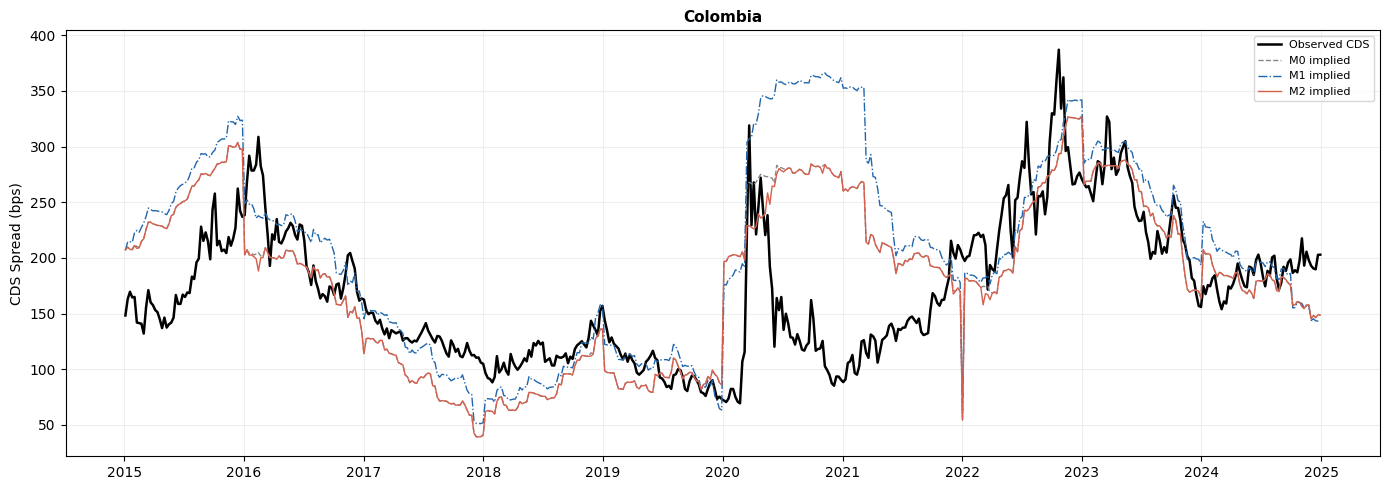

In [39]:
plot_cds_comparison('Colombia')

In [196]:
cds_df.to_csv('../output/results/cds_comparison.csv', index=False)

In [107]:
ALPHA_CALIBRATION = {}

df_m0 = pd.read_csv(PATHS['M0'], parse_dates=[DATE_COL],
                    usecols=[DATE_COL, COUNTRY_COL, DD_COL, CDS_COL])

for country in EXPORTERS + CONTROLS:
    cdf = df_m0[df_m0[COUNTRY_COL] == country].dropna(subset=[DD_COL, CDS_COL])

    mean_dd = cdf[DD_COL].mean()
    mean_pd = (1 - np.exp(-(cdf[CDS_COL] / 10000) / (1 - RECOVERY) * HORIZON)).mean()
    mean_pd = np.clip(mean_pd, 1e-6, 1 - 1e-6)

    ALPHA_CALIBRATION[country] = -norm.ppf(mean_pd) / mean_dd

print({k: round(v, 4) for k, v in ALPHA_CALIBRATION.items()})

{'Saudi Arabia': np.float64(0.2001), 'Abu Dhabi': np.float64(0.1341), 'Qatar': np.float64(0.1825), 'Colombia': np.float64(0.2385), 'Mexico': np.float64(0.2196), 'Brazil': np.float64(0.1294), 'Egypt': np.float64(0.0447), 'Malaysia': np.float64(0.16), 'Chile': np.float64(0.4185), 'China': np.float64(0.1415), 'Indonesia': np.float64(0.1831), 'Philippines': np.float64(0.1328), 'South Africa': np.float64(0.1981), 'South Korea': np.float64(0.169), 'Thailand': np.float64(0.1206), 'Turkey': np.float64(0.1617)}
